In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization, Input
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# Scikit-learn metrics
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)

In [ ]:
SCRIPT_DIR = os.getcwd()
OUTPUT_DIR = os.path.join(SCRIPT_DIR, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Plots will be saved to: {OUTPUT_DIR}")

Plots will be saved to: /content/outputs


In [ ]:
# Fashion-MNIST is a drop-in replacement for MNIST with 10 clothing categories
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Class names for Fashion-MNIST
CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print(f"Training set:   {X_train.shape} images, {y_train.shape} labels")
print(f"Test set:       {X_test.shape} images, {y_test.shape} labels")
print(f"Image shape:    {X_train[0].shape} (28x28 grayscale)")
print(f"Number of classes: {len(CLASS_NAMES)}")
print(f"Classes: {CLASS_NAMES}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training set:   (60000, 28, 28) images, (60000,) labels
Test set:       (10000, 28, 28) images, (10000,) labels
Image shape:    (28, 28) (28x28 grayscale)
Number of classes: 10
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [ ]:
# -- 4a. Normalize pixel values to [0, 1] --
# Raw pixel values are in [0, 255]. Normalizing helps the network
# converge faster and improves numerical stability.
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
print("Pixel values normalized to [0, 1]")

# -- 4b. Reshape for CNN input --
# Conv2D expects 4D input: (batch_size, height, width, channels)
# Fashion-MNIST is grayscale, so channels = 1
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)
print(f"Reshaped training data: {X_train.shape}")
print(f"Reshaped test data:     {X_test.shape}")

# -- 4c. One-hot encode labels --
# Convert integer labels to one-hot vectors for categorical crossentropy
NUM_CLASSES = 10
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)
print(f"One-hot encoded labels shape: {y_train_cat.shape}")

Pixel values normalized to [0, 1]
Reshaped training data: (60000, 28, 28, 1)
Reshaped test data:     (10000, 28, 28, 1)
One-hot encoded labels shape: (60000, 10)


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(CLASS_NAMES[y_train[i]], fontsize=11, fontweight='bold')
    ax.axis('off')
plt.suptitle('Sample Fashion-MNIST Images', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cnn_sample_images.png"), dpi=150, bbox_inches='tight')
plt.close()
print("Saved: cnn_sample_images.png")

Saved: cnn_sample_images.png


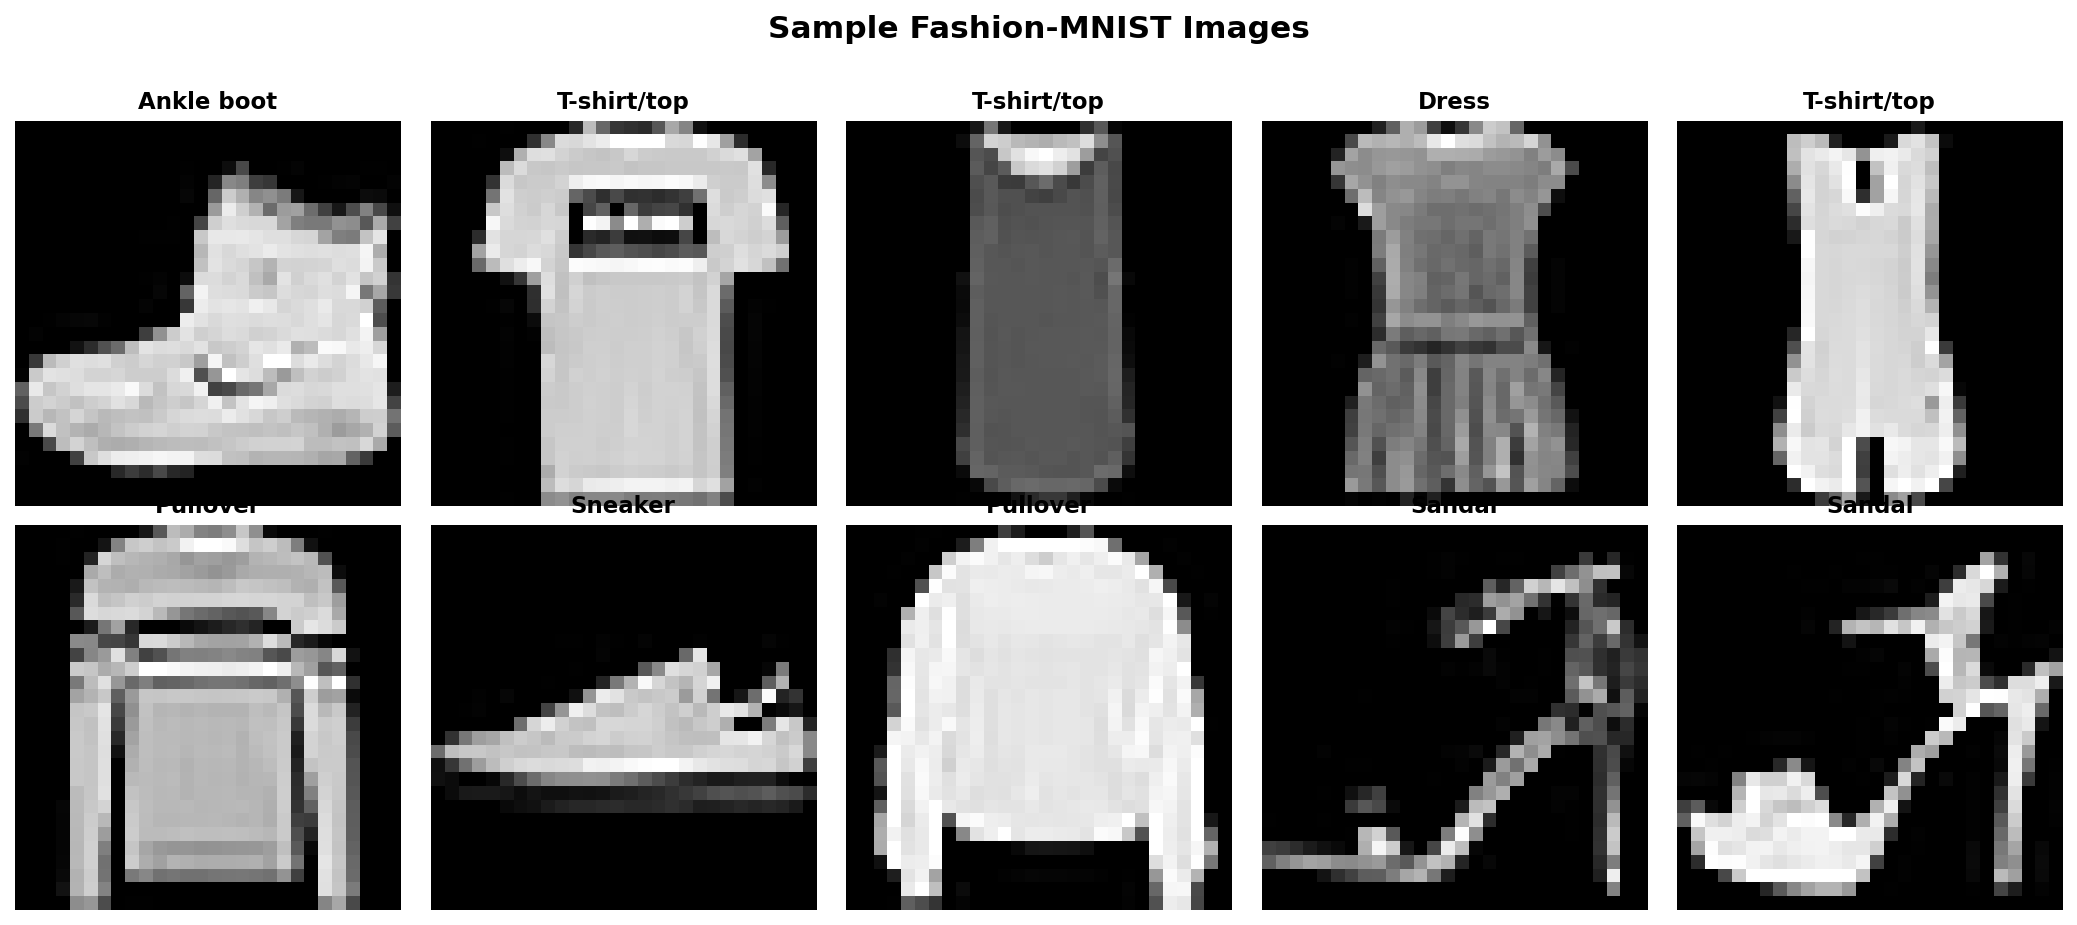

In [ ]:
from IPython.display import Image, display
image_path = os.path.join(OUTPUT_DIR, "cnn_sample_images.png")
display(Image(filename=image_path))

In [ ]:
def build_cnn_model():

    model = Sequential([
        Input(shape=(28, 28, 1)),

        # First Convolutional Block
        Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same',
               name='conv_block1'),
        BatchNormalization(name='bn_1'),
        MaxPooling2D(pool_size=(2, 2), name='maxpool_1'),

        # Second Convolutional Block
        Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same',
               name='conv_block2'),
        BatchNormalization(name='bn_2'),
        MaxPooling2D(pool_size=(2, 2), name='maxpool_2'),

        # Flatten and Dense Layers
        Flatten(name='flatten'),
        Dense(128, activation='relu', name='dense_1'),
        Dropout(0.4, name='dropout'),
        BatchNormalization(name='bn_3'),
        Dense(NUM_CLASSES, activation='softmax', name='output')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_cnn_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_block1 (Conv2D)            │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block2 (Conv2D)            │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,538 (1.61 MB)

 Trainable params: 422,090 (1.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Training parameters
EPOCHS = 20
BATCH_SIZE = 64

# Early stopping to prevent over-training
early_stop = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)

history = model.fit(
    X_train, y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,  # Use 15% of training data for validation
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
797/797 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8489 - loss: 0.4357 - val_accuracy: 0.8783 - val_loss: 0.3219
Epoch 2/20
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8949 - loss: 0.2934 - val_accuracy: 0.9056 - val_loss: 0.2570
Epoch 3/20
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9086 - loss: 0.2541 - val_accuracy: 0.9096 - val_loss: 0.2385
Epoch 4/20
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9181 - loss: 0.2254 - val_accuracy: 0.9103 - val_loss: 0.2478
Epoch 5/20
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9259 - loss: 0.2020 - val_accuracy: 0.9268 - val_loss: 0.2014
Epoch 6/20
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9317 - loss: 0.1858 - val_accuracy: 0.9170 - val_loss: 0.2278
Epoch 7/20
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9386 - loss: 0.1708 - val_accuracy: 0.9213 - val_loss: 0.2160
Epoch 8/20
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9417 - loss: 0.1575 - val_accuracy: 0

In [ ]:
# -- Overall test accuracy --
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# -- Predictions --
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# -- Per-class Metrics --
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

# -- Precision, Recall, F1 (weighted average) --
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\nWeighted Precision: {precision:.4f}")
print(f"Weighted Recall:    {recall:.4f}")
print(f"Weighted F1-Score:  {f1:.4f}")



Test Loss:     0.2225
Test Accuracy: 0.9190

--- Classification Report ---
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.91      0.87      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.87      0.90      0.88      1000
       Dress       0.91      0.93      0.92      1000
        Coat       0.85      0.89      0.87      1000
      Sandal       0.99      0.98      0.99      1000
       Shirt       0.82      0.68      0.75      1000
     Sneaker       0.96      0.97      0.97      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.97      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000


Weighted Precision: 0.9187
Weighted Recall:    0.9190
Weighted F1-Score:  0.9180


In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')

# -- Plot 1: Accuracy Curves --
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_title('Training & Validation Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# -- Plot 2: Loss Curves --
axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_title('Training & Validation Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cnn_accuracy_loss_curves.png"), dpi=150, bbox_inches='tight')
plt.close()
print("Saved: cnn_accuracy_loss_curves.png")

# -- Plot 3: Confusion Matrix --
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax.set_title('CNN Confusion Matrix — Fashion-MNIST', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cnn_confusion_matrix.png"), dpi=150, bbox_inches='tight')
plt.close()
print("Saved: cnn_confusion_matrix.png")

# -- Plot 4: Sample Predictions --
fig, axes = plt.subplots(3, 5, figsize=(16, 10))
# Pick some interesting examples (mix of correct and potentially wrong)
indices = np.random.choice(len(X_test), 15, replace=False)

for i, ax in enumerate(axes.flat):
    idx = indices[i]
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    true_label = CLASS_NAMES[y_test[idx]]
    pred_label = CLASS_NAMES[y_pred[idx]]
    confidence = y_pred_prob[idx][y_pred[idx]] * 100

    # Color code: green for correct, red for incorrect
    color = 'green' if y_test[idx] == y_pred[idx] else 'red'
    ax.set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.0f}%)",
                 fontsize=9, color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cnn_sample_predictions.png"), dpi=150, bbox_inches='tight')
plt.close()
print("Saved: cnn_sample_predictions.png")

Saved: cnn_accuracy_loss_curves.png
Saved: cnn_confusion_matrix.png
Saved: cnn_sample_predictions.png


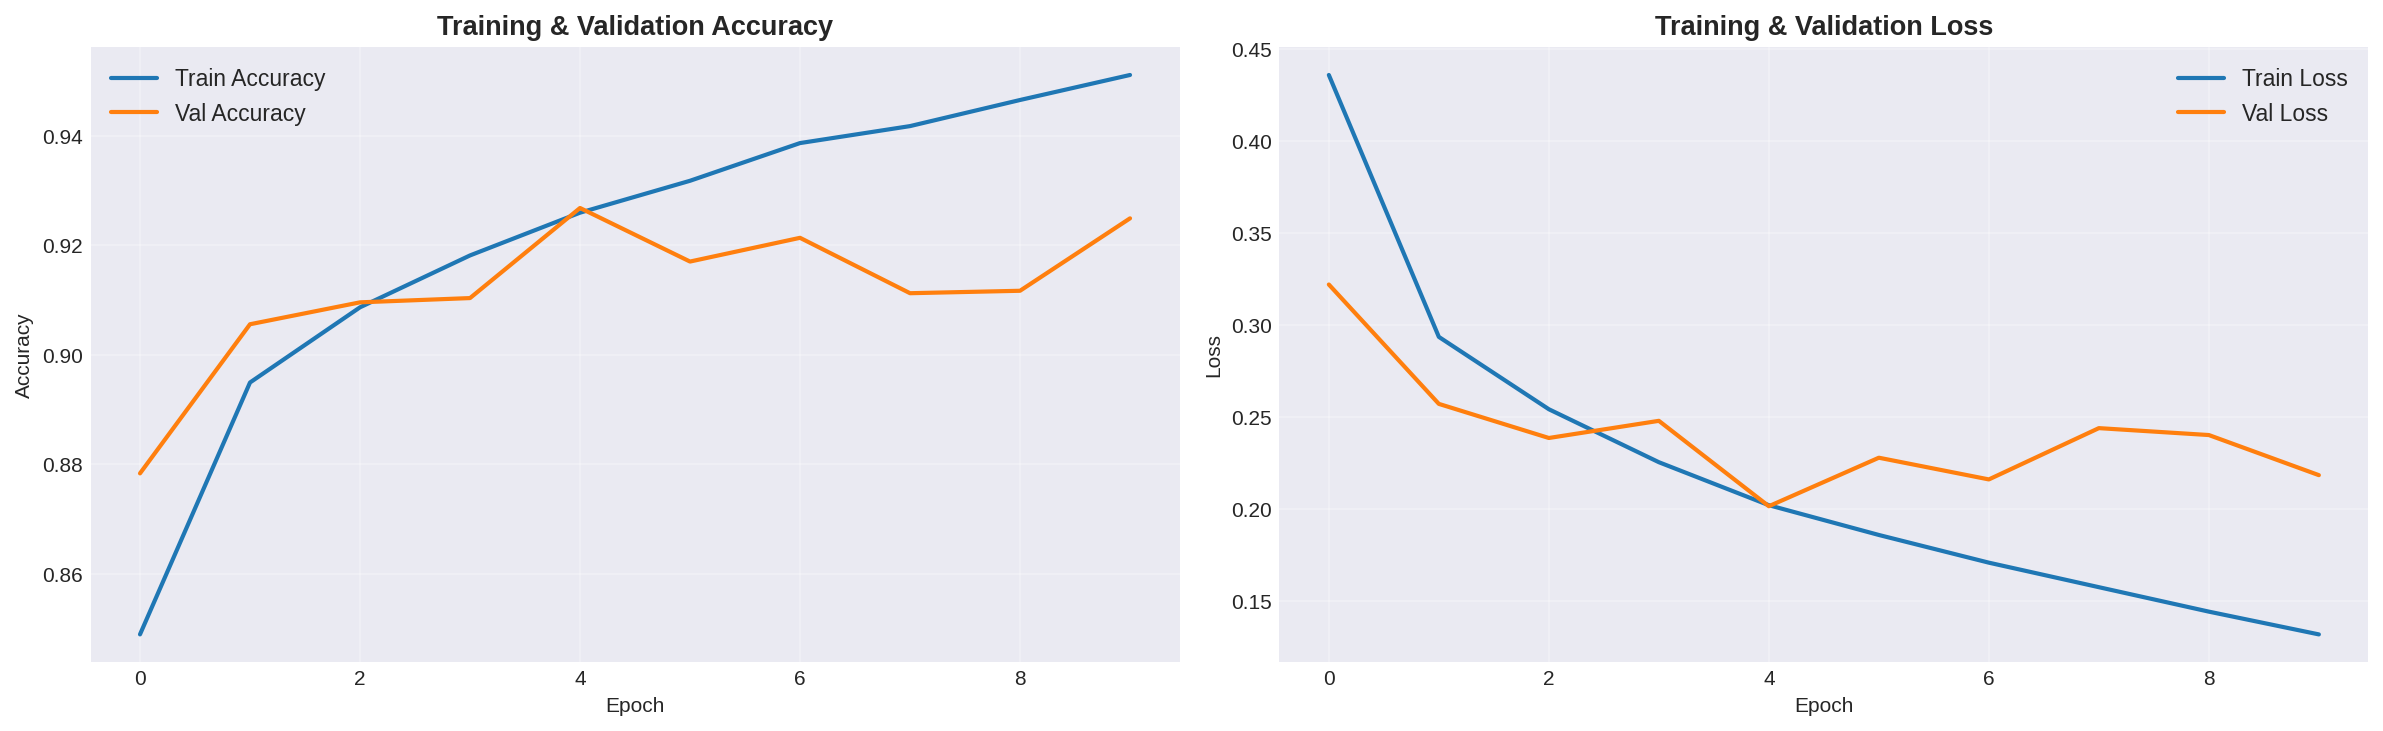

In [ ]:
from IPython.display import Image, display
image_path_acc_loss = os.path.join(OUTPUT_DIR, "cnn_accuracy_loss_curves.png")
display(Image(filename=image_path_acc_loss))

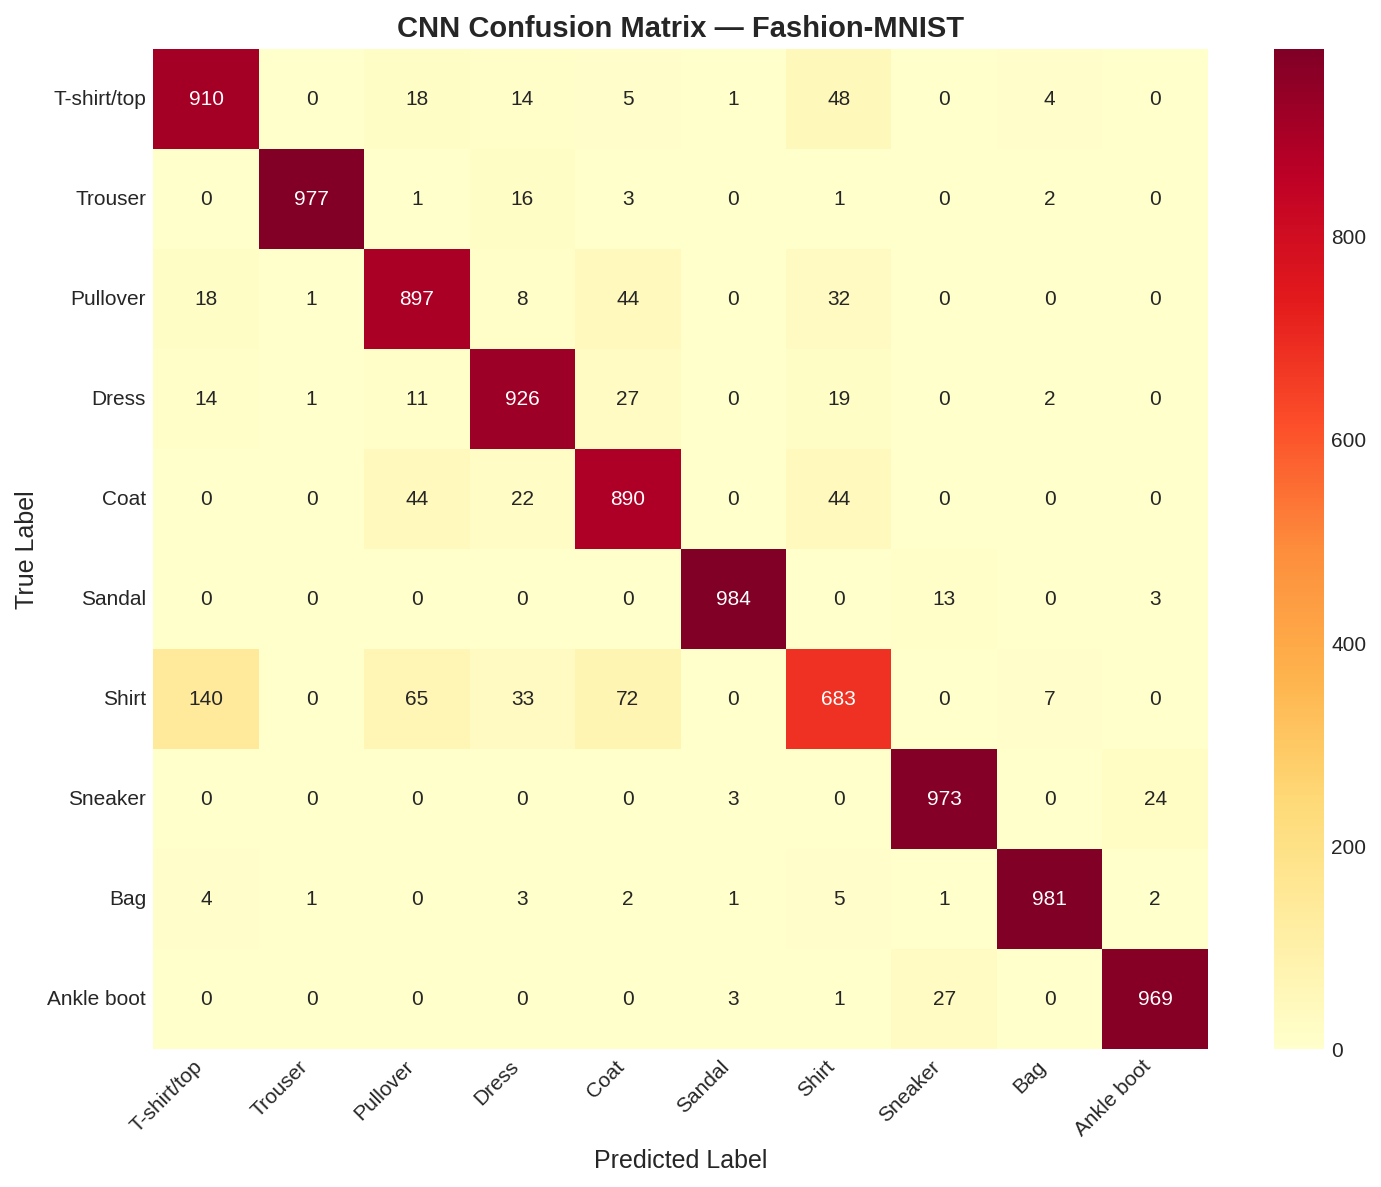

In [ ]:
image_path_cm = os.path.join(OUTPUT_DIR, "cnn_confusion_matrix.png")
display(Image(filename=image_path_cm))

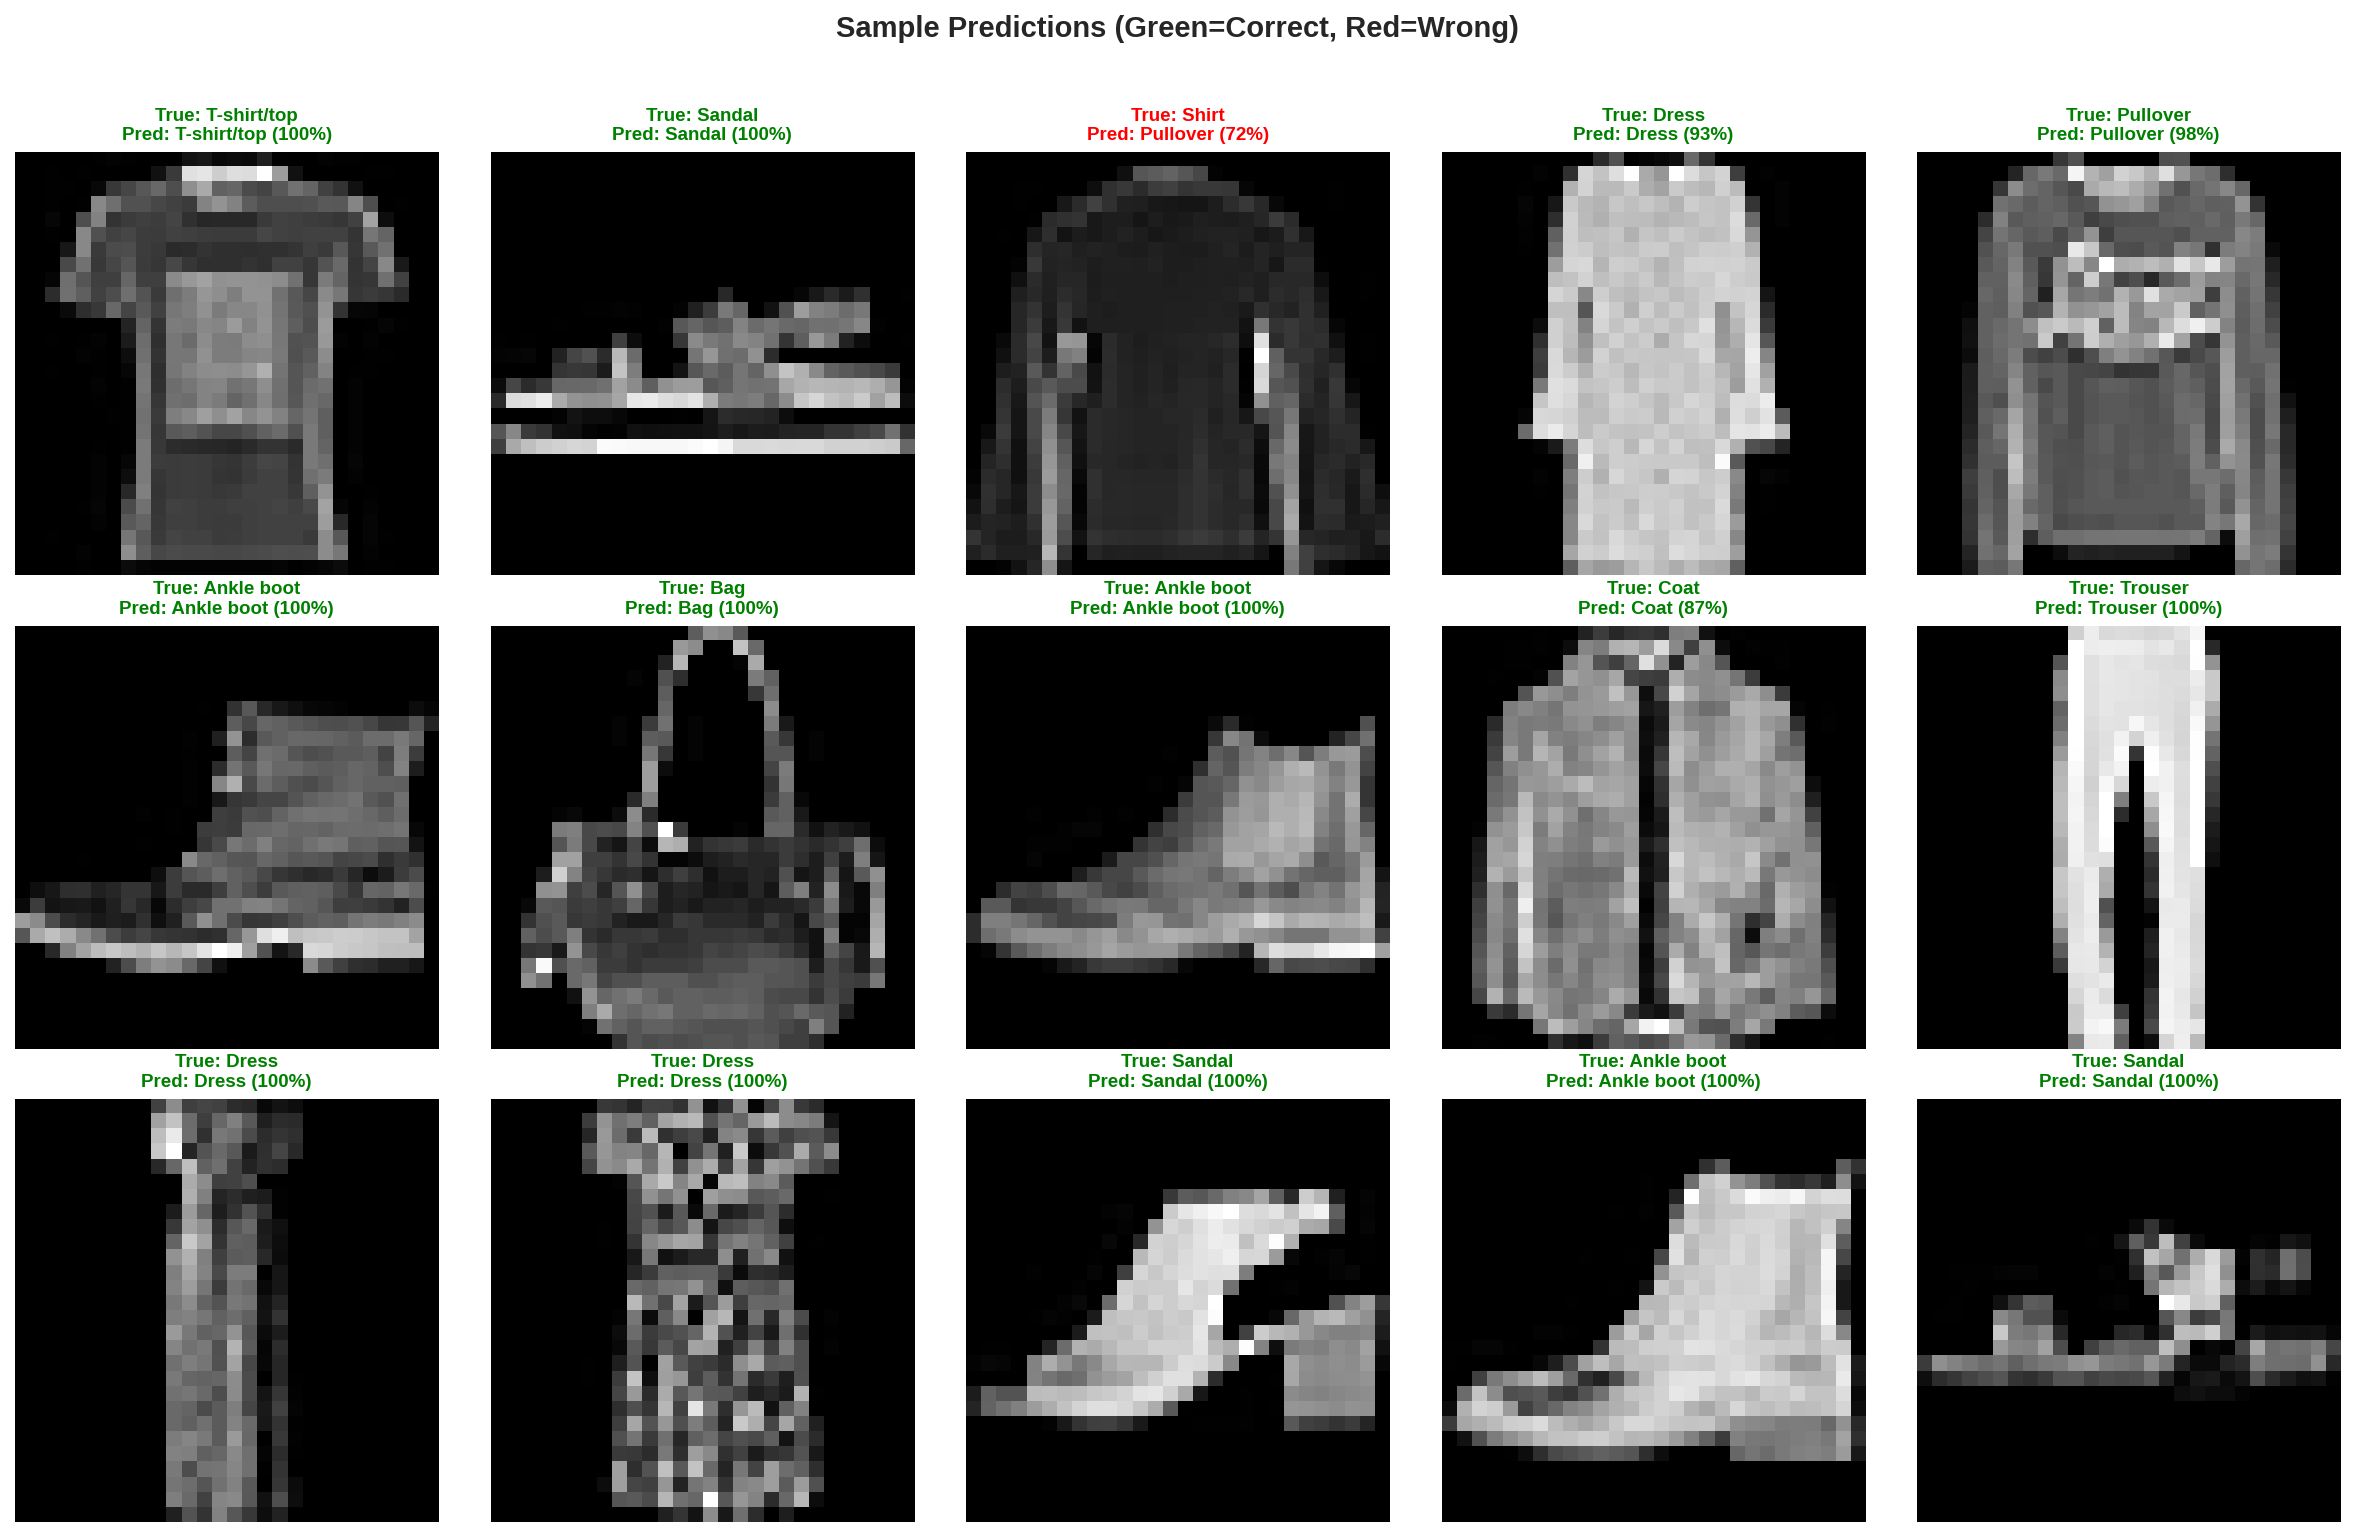

In [ ]:
image_path_preds = os.path.join(OUTPUT_DIR, "cnn_sample_predictions.png")
display(Image(filename=image_path_preds))